In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')

tickers = {
    "RELIANCE": "RELIANCE.NS",
    "TCS":      "TCS.NS",
    "INFY":     "INFY.NS"
}

all_data = []

for name, symbol in tickers.items():
    print(f"Downloading {name}...")
    df = yf.download(symbol, start=START_DATE, end=END_DATE,
                     interval='1d', auto_adjust=True)
    df = df.reset_index()
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df['Ticker'] = name
    all_data.append(df)
    print(f"  Got {len(df)} rows")

raw_df = pd.concat(all_data, ignore_index=True)
raw_df = raw_df[['Ticker','Date','Open','High','Low','Close','Volume']]
raw_df = raw_df.sort_values(['Ticker','Date']).reset_index(drop=True)

print(f"\nTotal rows downloaded: {len(raw_df)}")
raw_df.head()

[*********************100%***********************]  1 of 1 completed


  Got 247 rows


[*********************100%***********************]  1 of 1 completed


  Got 247 rows


[*********************100%***********************]  1 of 1 completed

  Got 247 rows

Total rows downloaded: 741


,Ticker,Date,Open,High,Low,Close,Volume
0,INFY,2025-04-01,1495.006198,1502.921960,1474.221290,1482.622681,12680733
1,INFY,2025-04-02,1491.072664,1510.934927,1491.072664,1505.593018,6193478
2,INFY,2025-04-03,1490.538435,1490.538435,1442.364149,1453.484985,10459504
3,INFY,2025-04-04,1418.519789,1429.689236,1406.379085,1409.924194,9590254
4,INFY,2025-04-07,1313.138574,1365.489314,1269.432038,1356.602295,21715252


In [4]:
raw_df.to_csv('../data/raw/raw_stock_data.csv', index=False)
print("Raw data saved!")

Raw data saved!


In [5]:

df = raw_df.copy()

df['Date']   = pd.to_datetime(df['Date'])
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce').round(2)

print("Missing values:")
print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates(subset=['Ticker', 'Date'])
df = df[df['Volume'] > 0]
df = df[df['High'] >= df['Low']]

df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change().round(4)

df['MA7'] = df.groupby('Ticker')['Close'].transform(
    lambda x: x.rolling(7).mean()
).round(2)

df['MA21'] = df.groupby('Ticker')['Close'].transform(
    lambda x: x.rolling(21).mean()
).round(2)

df['Price_Range'] = (df['High'] - df['Low']).round(2)

print(f"Clean rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Missing values:
Ticker    0
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Clean rows: 738
Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA7', 'MA21', 'Price_Range']


,Ticker,Date,Open,High,Low,Close,Volume,Daily_Return,MA7,MA21,Price_Range
0,INFY,2025-04-01,1495.01,1502.92,1474.22,1482.62,12680733,NaN,NaN,NaN,28.70
1,INFY,2025-04-02,1491.07,1510.93,1491.07,1505.59,6193478,0.0155,NaN,NaN,19.86
2,INFY,2025-04-03,1490.54,1490.54,1442.36,1453.48,10459504,-0.0346,NaN,NaN,48.18
3,INFY,2025-04-04,1418.52,1429.69,1406.38,1409.92,9590254,-0.0300,NaN,NaN,23.31
4,INFY,2025-04-07,1313.14,1365.49,1269.43,1356.60,21715252,-0.0378,NaN,NaN,96.06


In [6]:
os.makedirs('../data/raw/cleaned', exist_ok=True)
df.to_csv('../data/raw/cleaned/cleaned_stock_data.csv', index=False)
print("Cleaned data saved!")
print(df.tail(3).to_string(index=False))

NameError: name 'os' is not defined

In [7]:
import os

In [8]:
os.makedirs('../data/raw/cleaned', exist_ok=True)
df.to_csv('../data/raw/cleaned/cleaned_stock_data.csv', index=False)
print("Cleaned data saved!")
print(df.tail(3).to_string(index=False))


Cleaned data saved!
Ticker       Date   Open   High    Low  Close  Volume  Daily_Return     MA7    MA21  Price_Range
   TCS 2026-03-25 2400.9 2421.6 2369.8 2377.4 5843778       -0.0089 2391.30 2492.02         51.8
   TCS 2026-03-27 2403.9 2422.1 2385.0 2389.8 4979411        0.0052 2391.03 2483.26         37.1
   TCS 2026-03-30 2375.1 2398.0 2346.2 2358.9 6804756       -0.0129 2379.33 2470.39         51.8


In [9]:
print("=== DATA SUMMARY ===")
print(f"Total rows : {len(df)}")
print(f"Date range : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stocks     : {df['Ticker'].unique()}")
print(f"Columns    : {list(df.columns)}")
print("\nRows per stock:")
print(df['Ticker'].value_counts())
print("\nSample data:")
df.sample(5)

=== DATA SUMMARY ===
Total rows : 738
Date range : 2025-04-01 to 2026-03-30
Stocks     : <StringArray>
['INFY', 'RELIANCE', 'TCS']
Length: 3, dtype: str
Columns    : ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA7', 'MA21', 'Price_Range']

Rows per stock:
Ticker
INFY        246
RELIANCE    246
TCS         246
Name: count, dtype: int64

Sample data:


,Ticker,Date,Open,High,Low,Close,Volume,Daily_Return,MA7,MA21,Price_Range
427,RELIANCE,2025-12-23,1580.90,1580.90,1568.10,1570.70,7506564,-0.0030,1556.93,1551.30,12.80
144,INFY,2025-10-30,1507.00,1508.20,1489.10,1493.80,5608867,-0.0110,1495.28,1465.47,19.10
7,INFY,2025-04-11,1370.69,1397.44,1356.89,1368.94,12567440,0.0041,1406.52,NaN,40.55
610,TCS,2025-09-22,3028.45,3040.09,2999.09,3007.70,3634901,-0.0301,3072.97,3041.81,41.00
31,INFY,2025-05-20,1524.87,1537.98,1513.22,1515.74,7143998,0.0005,1541.69,1477.49,24.76


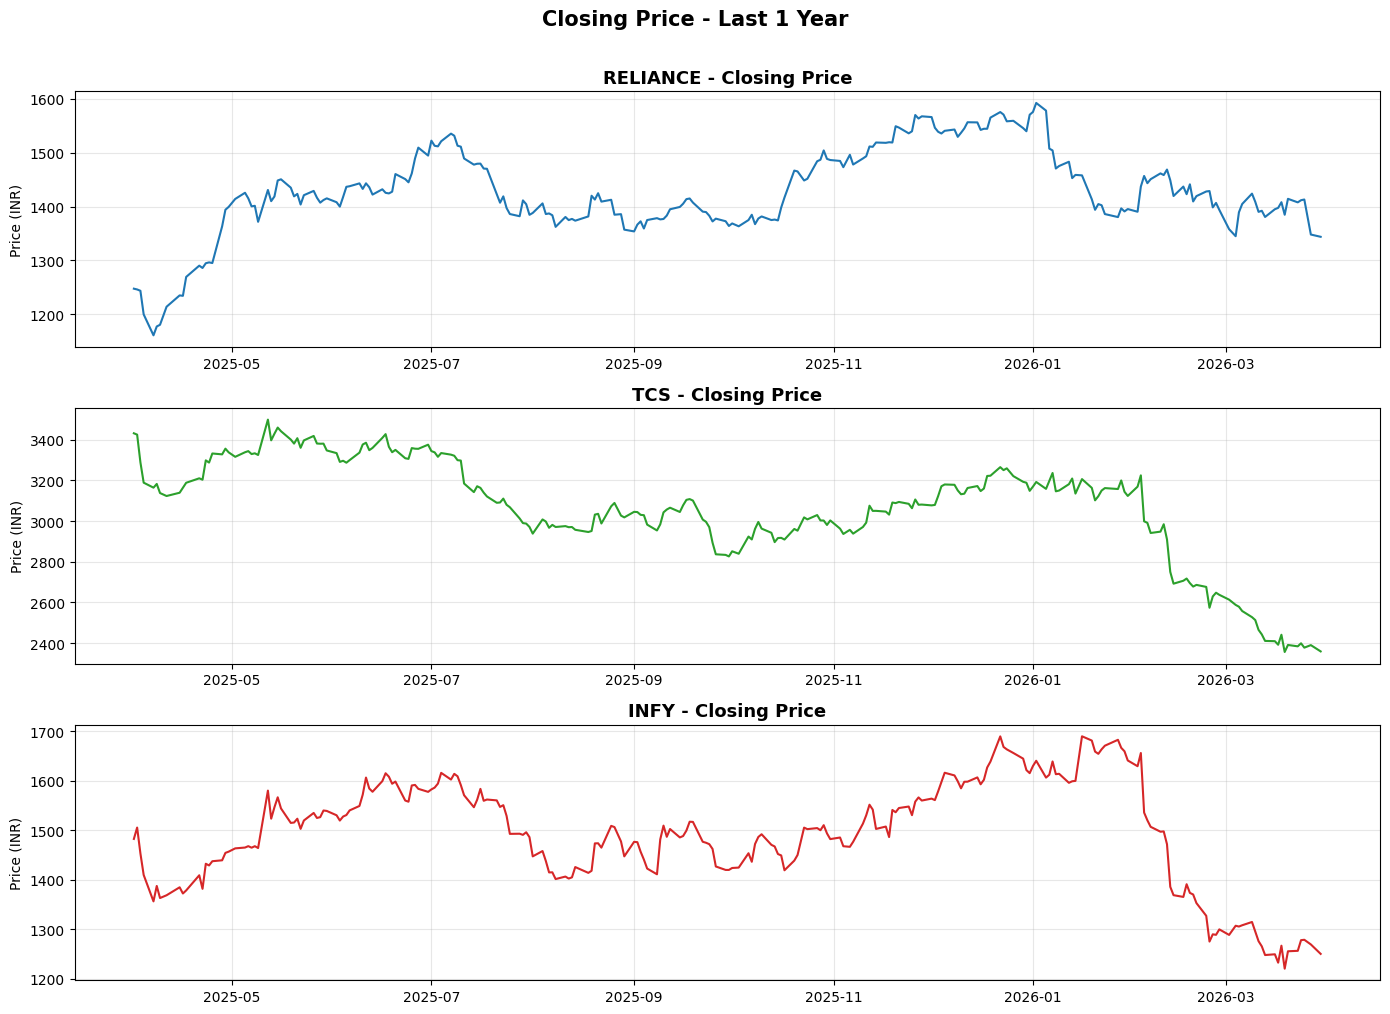

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
stocks = ['RELIANCE', 'TCS', 'INFY']
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, stock in enumerate(stocks):
    data = df[df['Ticker'] == stock]
    axes[i].plot(data['Date'], data['Close'], color=colors[i], linewidth=1.5)
    axes[i].set_title(f'{stock} - Closing Price', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Price (INR)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Closing Price - Last 1 Year', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

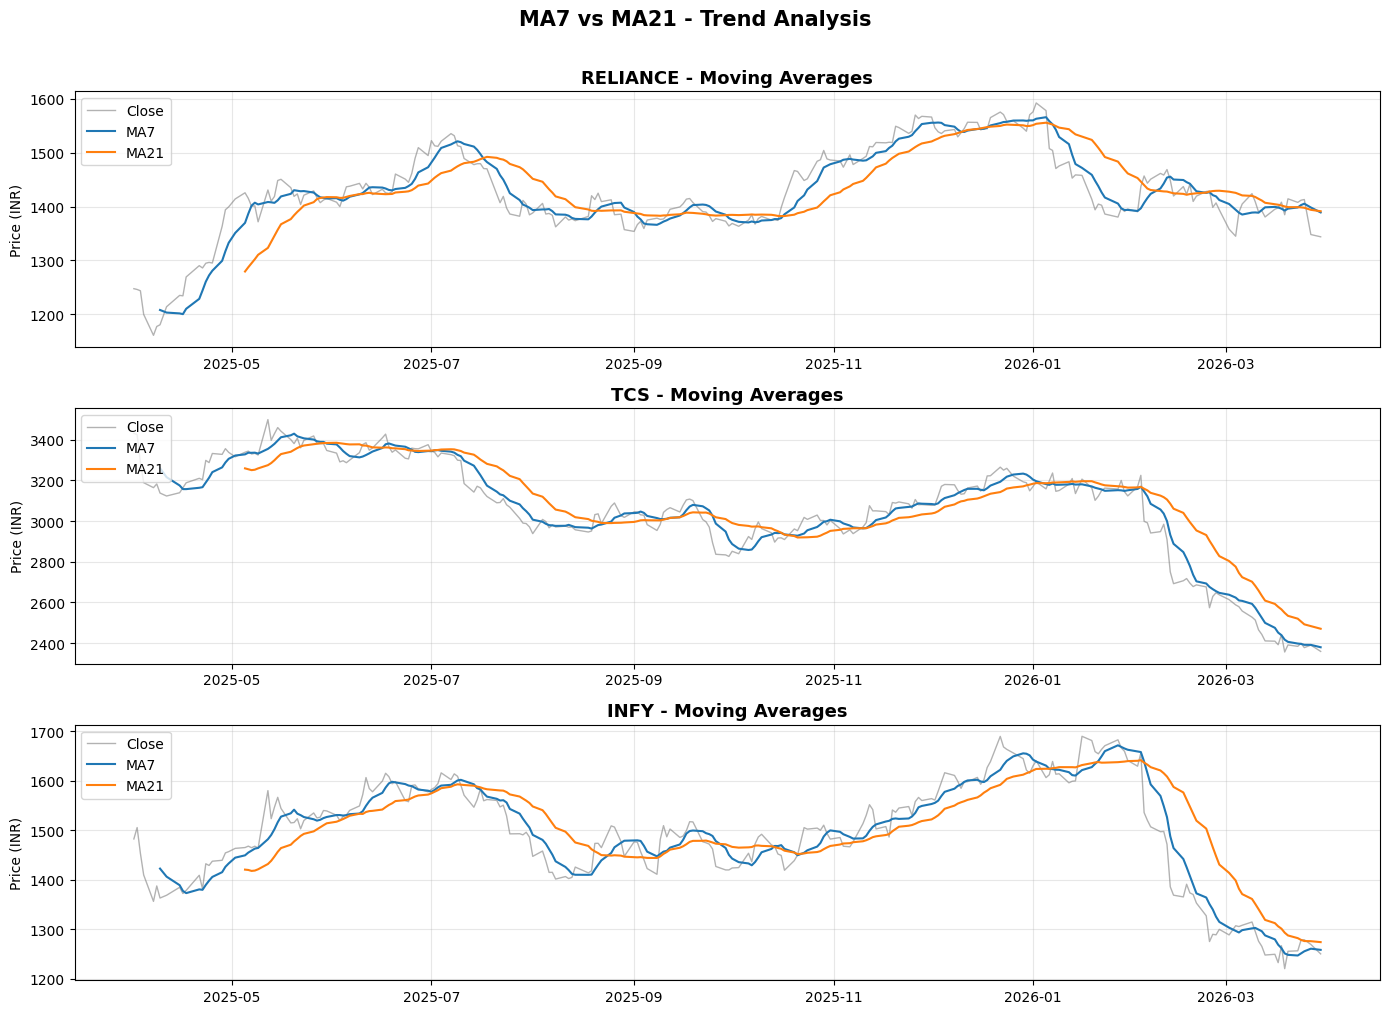

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
stocks = ['RELIANCE', 'TCS', 'INFY']

for i, stock in enumerate(stocks):
    data = df[df['Ticker'] == stock]
    axes[i].plot(data['Date'], data['Close'], label='Close',  color='gray',    linewidth=1,   alpha=0.6)
    axes[i].plot(data['Date'], data['MA7'],   label='MA7',   color='#1f77b4', linewidth=1.5)
    axes[i].plot(data['Date'], data['MA21'],  label='MA21',  color='#ff7f0e', linewidth=1.5)
    axes[i].set_title(f'{stock} - Moving Averages', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Price (INR)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('MA7 vs MA21 - Trend Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

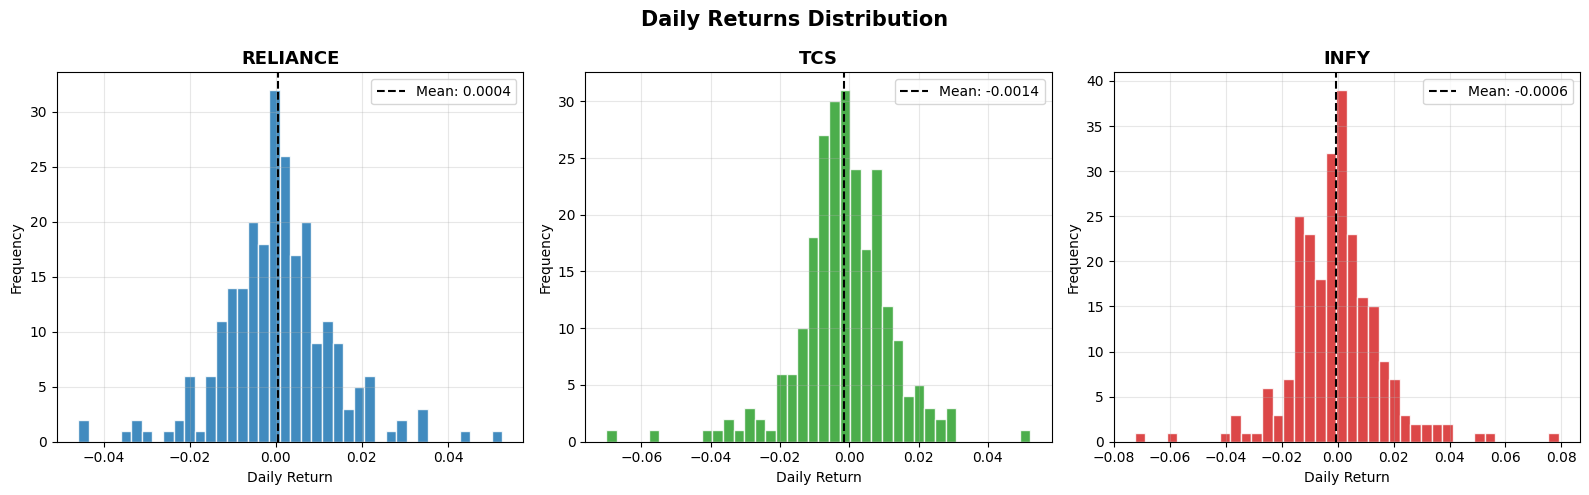

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
stocks = ['RELIANCE', 'TCS', 'INFY']
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, stock in enumerate(stocks):
    data = df[df['Ticker'] == stock]['Daily_Return'].dropna()
    axes[i].hist(data, bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.4f}')
    axes[i].set_title(f'{stock}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Daily Returns Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

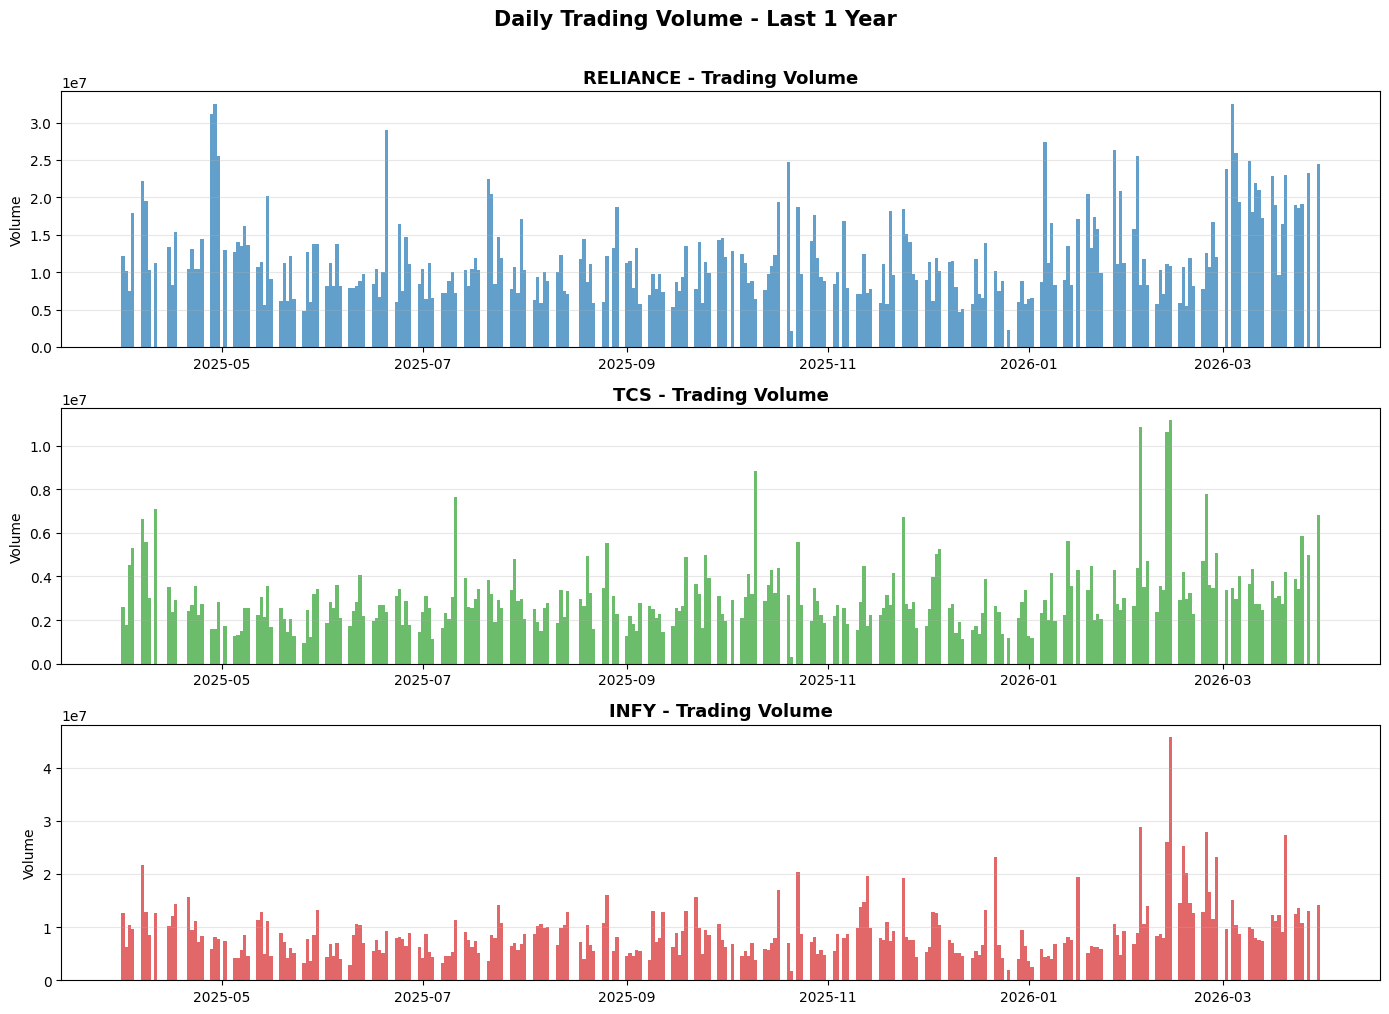

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
stocks = ['RELIANCE', 'TCS', 'INFY']
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, stock in enumerate(stocks):
    data = df[df['Ticker'] == stock]
    axes[i].bar(data['Date'], data['Volume'], color=colors[i], alpha=0.7, width=1)
    axes[i].set_title(f'{stock} - Trading Volume', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Volume')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Daily Trading Volume - Last 1 Year', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

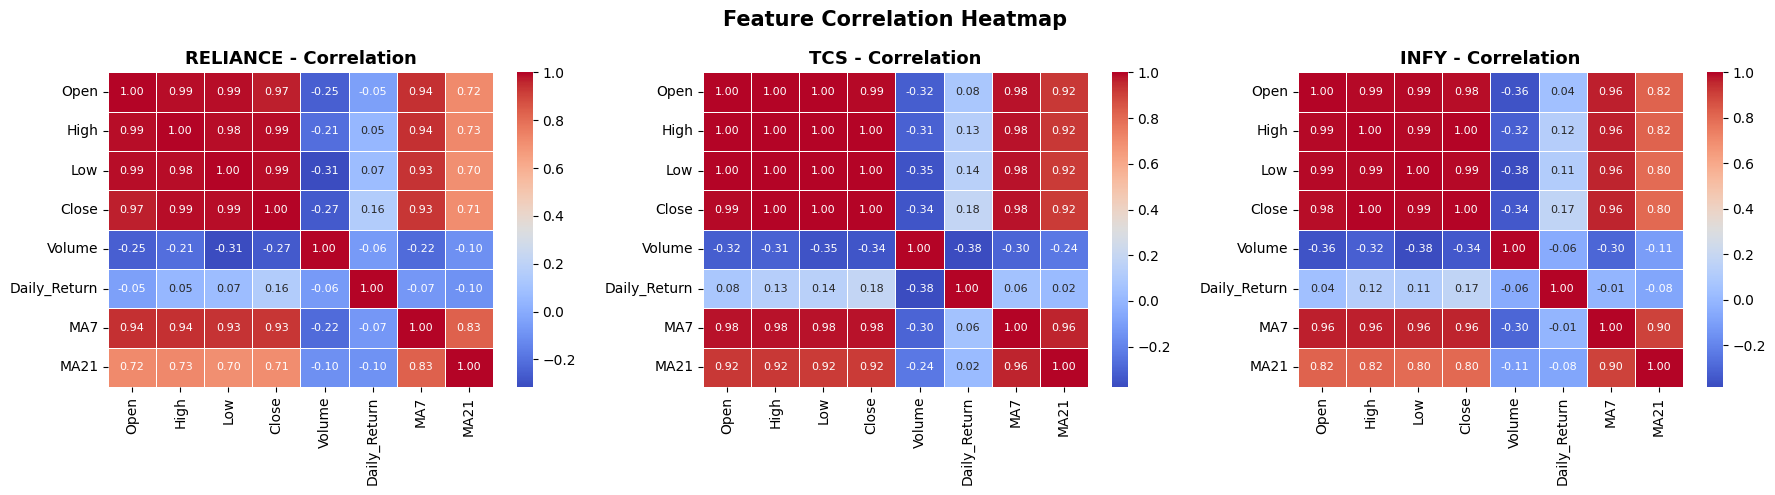

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
stocks = ['RELIANCE', 'TCS', 'INFY']

for i, stock in enumerate(stocks):
    data = df[df['Ticker'] == stock][['Open','High','Low','Close','Volume','Daily_Return','MA7','MA21']].dropna()
    corr = data.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                ax=axes[i], linewidths=0.5, annot_kws={'size': 8})
    axes[i].set_title(f'{stock} - Correlation', fontsize=13, fontweight='bold')

plt.suptitle('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
df = pd.read_csv('../data/raw/cleaned/cleaned_stock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
print(df.head())

(738, 11)
  Ticker       Date     Open     High      Low    Close    Volume  \
0   INFY 2025-04-01  1495.01  1502.92  1474.22  1482.62  12680733   
1   INFY 2025-04-02  1491.07  1510.93  1491.07  1505.59   6193478   
2   INFY 2025-04-03  1490.54  1490.54  1442.36  1453.48  10459504   
3   INFY 2025-04-04  1418.52  1429.69  1406.38  1409.92   9590254   
4   INFY 2025-04-07  1313.14  1365.49  1269.43  1356.60  21715252   

   Daily_Return  MA7  MA21  Price_Range  
0           NaN  NaN   NaN        28.70  
1        0.0155  NaN   NaN        19.86  
2       -0.0346  NaN   NaN        48.18  
3       -0.0300  NaN   NaN        23.31  
4       -0.0378  NaN   NaN        96.06  
